# Poisson Diffusion Process 테스트 및 시각화

이 노트북은 `prior_poisson_diffusion.py`의 forward/backward diffusion process를 테스트하고 시각화합니다.

In [3]:
import autorootcwd
from src.diffusion.prior_poisson_diffusion import PriorPoissonDiffusion, get_named_beta_schedule, ModelMeanType, LossType
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.distributions.poisson import Poisson
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

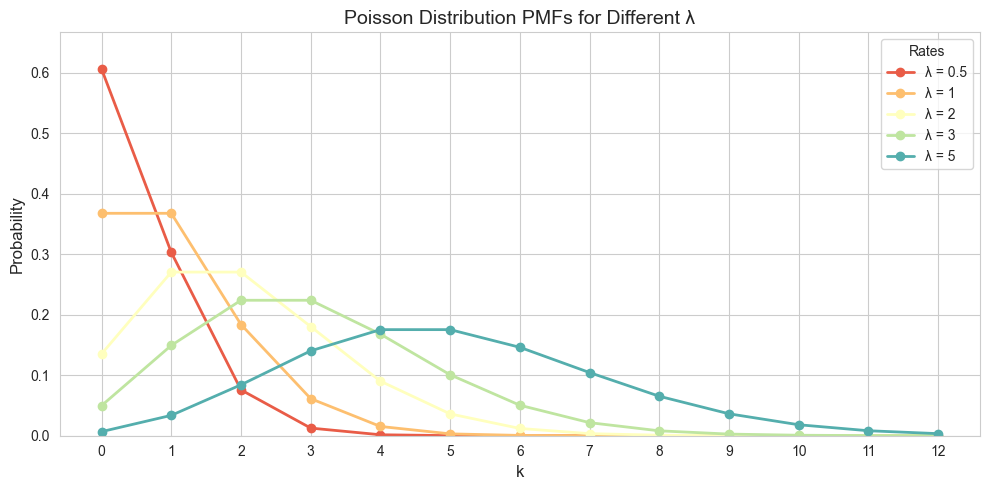

In [7]:
# Visualize Poisson PMFs for multiple rates
lambdas = [0.5, 1, 2, 3, 5]
k = torch.arange(0, 13, dtype=torch.float32)

plt.figure(figsize=(10, 5))
colors = sns.color_palette("Spectral", len(lambdas))
max_prob = 0.0

for lam, color in zip(lambdas, colors):
    dist = Poisson(torch.tensor([lam], dtype=torch.float32))
    probs = dist.log_prob(k).exp().cpu().numpy().flatten()
    max_prob = max(max_prob, probs.max())
    plt.plot(k.numpy(), probs, marker="o", linewidth=2, label=rf"λ = {lam}", color=color)

plt.xlabel("k", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.title("Poisson Distribution PMFs for Different λ", fontsize=14)
plt.xticks(k.numpy())
plt.ylim(0, max_prob * 1.1)
plt.legend(title="Rates", loc="upper right")
plt.tight_layout()
plt.show()

## 1. Setup and Configuration

In [2]:
# Set device
from src.model.unet import SegmentationModel


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Diffusion parameters
num_timesteps = 1000
noise_schedule = "linear"

# Get beta schedule
betas = get_named_beta_schedule(noise_schedule, num_timesteps)

# create diffusion backbone
model = SegmentationModel(
    in_channels=1,
    img_channels=1,
    out_channels=1,
    model_channels=64,
    num_res_blocks=2,
    attention_resolutions=[16, 8],
).to(device)
# Create diffusion model
diffusion = PriorPoissonDiffusion(
    betas=betas,
    model_mean_type=ModelMeanType.START_Y,
    loss_type=LossType.MIX,
    rescale_timesteps=True,
)

print(f"Number of timesteps: {diffusion.num_timesteps}")
print(f"Beta schedule shape: {diffusion.betas.shape}")
print(f"Alpha cumulative product shape: {diffusion.alphas_cumprod.shape}")

Using device: cuda:0
Number of timesteps: 1000
Beta schedule shape: (1000,)
Alpha cumulative product shape: (1000,)
Number of timesteps: 1000
Beta schedule shape: (1000,)
Alpha cumulative product shape: (1000,)


## 2. Visualize Beta Schedule and Alpha Values

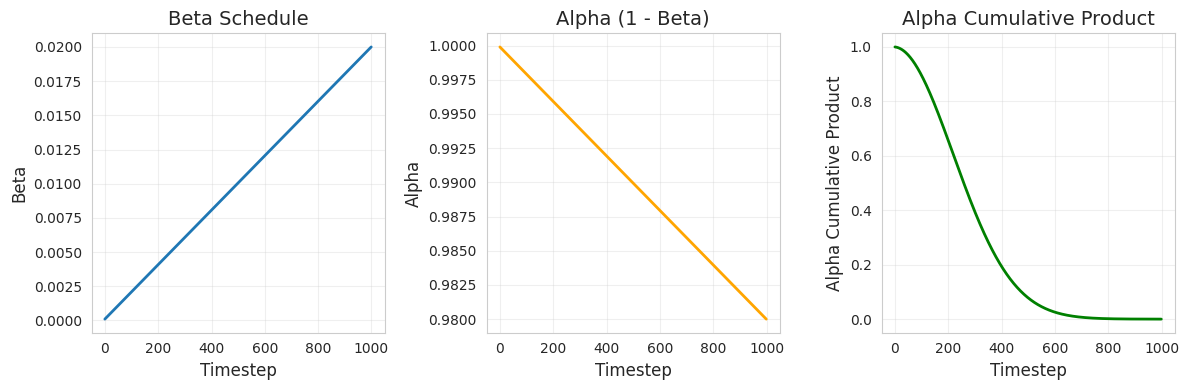

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot betas
axes[0].plot(diffusion.betas, linewidth=2)
axes[0].set_xlabel('Timestep', fontsize=12)
axes[0].set_ylabel('Beta', fontsize=12)
axes[0].set_title('Beta Schedule', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Plot alphas
axes[1].plot(diffusion.alphas, linewidth=2, color='orange')
axes[1].set_xlabel('Timestep', fontsize=12)
axes[1].set_ylabel('Alpha', fontsize=12)
axes[1].set_title('Alpha (1 - Beta)', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Plot cumulative alphas
axes[2].plot(diffusion.alphas_cumprod, linewidth=2, color='green')
axes[2].set_xlabel('Timestep', fontsize=12)
axes[2].set_ylabel('Alpha Cumulative Product', fontsize=12)
axes[2].set_title('Alpha Cumulative Product', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Create Test Data

In [4]:
# Load real data from OCTA500_6M/FRUnet
from PIL import Image
import glob

data_dir = 'data/OCTA500_6M/FRUnet/train'
batch_size = 4
channels = 1

# Load a few samples
mask_files = sorted(glob.glob(f'{data_dir}/batch_*_mask.jpg'))[:batch_size]
image_files = sorted(glob.glob(f'{data_dir}/batch_*_image.jpg'))[:batch_size]

y_start_list = []
prior_list = []

for mask_file, image_file in zip(mask_files, image_files):
    # Load ground truth mask
    mask = Image.open(mask_file).convert('L')
    mask = np.array(mask, dtype=np.float32) / 255.0

    # Load prior (FRUnet prediction)
    prior_img = Image.open(image_file).convert('L')
    prior_img = np.array(prior_img, dtype=np.float32) / 255.0

    # Keep original size or resize if needed
    y_start_list.append(mask)
    prior_list.append(prior_img)

# Convert to tensors
y_start = torch.tensor(np.array(y_start_list), dtype=torch.float32).unsqueeze(1)
prior = torch.tensor(np.array(prior_list), dtype=torch.float32).unsqueeze(1)

# Ensure prior is in valid range for Poisson distribution
prior = torch.clamp(prior, 0.01, 0.99)

y_start = y_start.to(device)
prior = prior.to(device)

img_h, img_w = y_start.shape[2], y_start.shape[3]

print(f"Loaded {batch_size} samples from {data_dir}")
print(f"Ground truth shape: {y_start.shape}")
print(f"Prior shape: {prior.shape}")
print(f"Image size: {img_h}x{img_w}")
print(f"Ground truth range: [{y_start.min():.3f}, {y_start.max():.3f}]")
print(f"Prior range: [{prior.min():.3f}, {prior.max():.3f}]")

Loaded 4 samples from data/OCTA500_6M/FRUnet/train
Ground truth shape: torch.Size([4, 1, 400, 400])
Prior shape: torch.Size([4, 1, 400, 400])
Image size: 400x400
Ground truth range: [0.000, 1.000]
Prior range: [0.010, 0.990]


## 4. Visualize Ground Truth and Prior

gt 0.0 1.0
prior_img 0.01 0.99
gt 0.0 1.0
prior_img 0.01 0.99
gt 0.0 1.0
prior_img 0.01 0.99
gt 0.0 1.0
prior_img 0.01 0.99


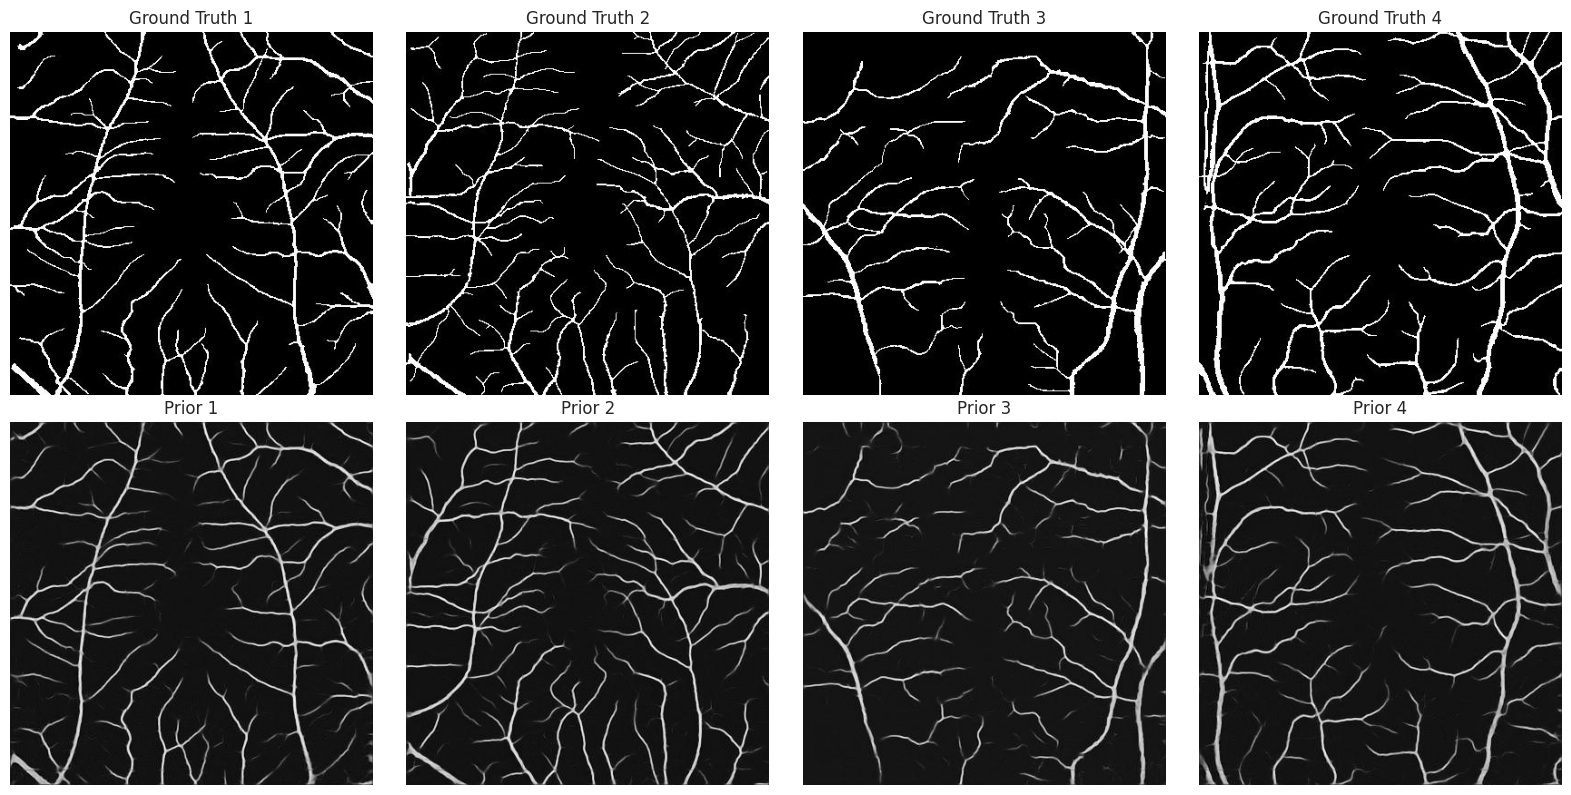

In [5]:
fig, axes = plt.subplots(2, batch_size, figsize=(batch_size*4, 8))

for i in range(batch_size):
    # Ground truth
    gt = y_start[i, 0].cpu().numpy()
    print("gt", gt.min(), gt.max())
    axes[0, i].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Ground Truth {i+1}', fontsize=12)
    axes[0, i].axis('off')

    # Prior
    prior_img = prior[i, 0].cpu().numpy()
    print("prior_img", prior_img.min(), prior_img.max())
    axes[1, i].imshow(prior_img, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Prior {i+1}', fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 5. Forward Process Visualization

여러 timestep에서 forward diffusion process를 시각화합니다.

In [6]:
# Select specific timesteps to visualize
timesteps_to_visualize = [0, 50, 100, 200, 400, 600, 800, 999]
num_steps = len(timesteps_to_visualize)

# Sample from forward process at different timesteps
forward_samples = []
forward_means = []

for t_val in timesteps_to_visualize:
    t = torch.tensor([t_val] * batch_size, device=device)

    # Get mean of q(y_t | y_0, prior)
    mean = diffusion.q_mean(y_start, prior, t)
    forward_means.append(mean)

    # Sample from forward process
    y_t = Poisson(mean).sample()
    forward_samples.append(y_t)

print(f"Generated {len(forward_samples)} forward process samples")

Generated 8 forward process samples


mean 	 0.0000 	 0.0858 	 1.0000
sample 	 0.0000 	 0.0856 	 7.0000
mean 	 0.0003 	 0.0871 	 0.9997
sample 	 0.0000 	 0.0868 	 6.0000
mean 	 0.0010 	 0.0903 	 0.9990
sample 	 0.0000 	 0.0891 	 7.0000
mean 	 0.0034 	 0.1003 	 0.9966
sample 	 0.0000 	 0.0989 	 6.0000
mean 	 0.0081 	 0.1198 	 0.9919
sample 	 0.0000 	 0.1213 	 6.0000
mean 	 0.0097 	 0.1268 	 0.9903
sample 	 0.0000 	 0.1266 	 6.0000
mean 	 0.0100 	 0.1278 	 0.9900
sample 	 0.0000 	 0.1274 	 6.0000
mean 	 0.0100 	 0.1279 	 0.9900
sample 	 0.0000 	 0.1278 	 5.0000
mean 	 0.0100 	 0.1278 	 0.9900
sample 	 0.0000 	 0.1274 	 6.0000
mean 	 0.0100 	 0.1279 	 0.9900
sample 	 0.0000 	 0.1278 	 5.0000


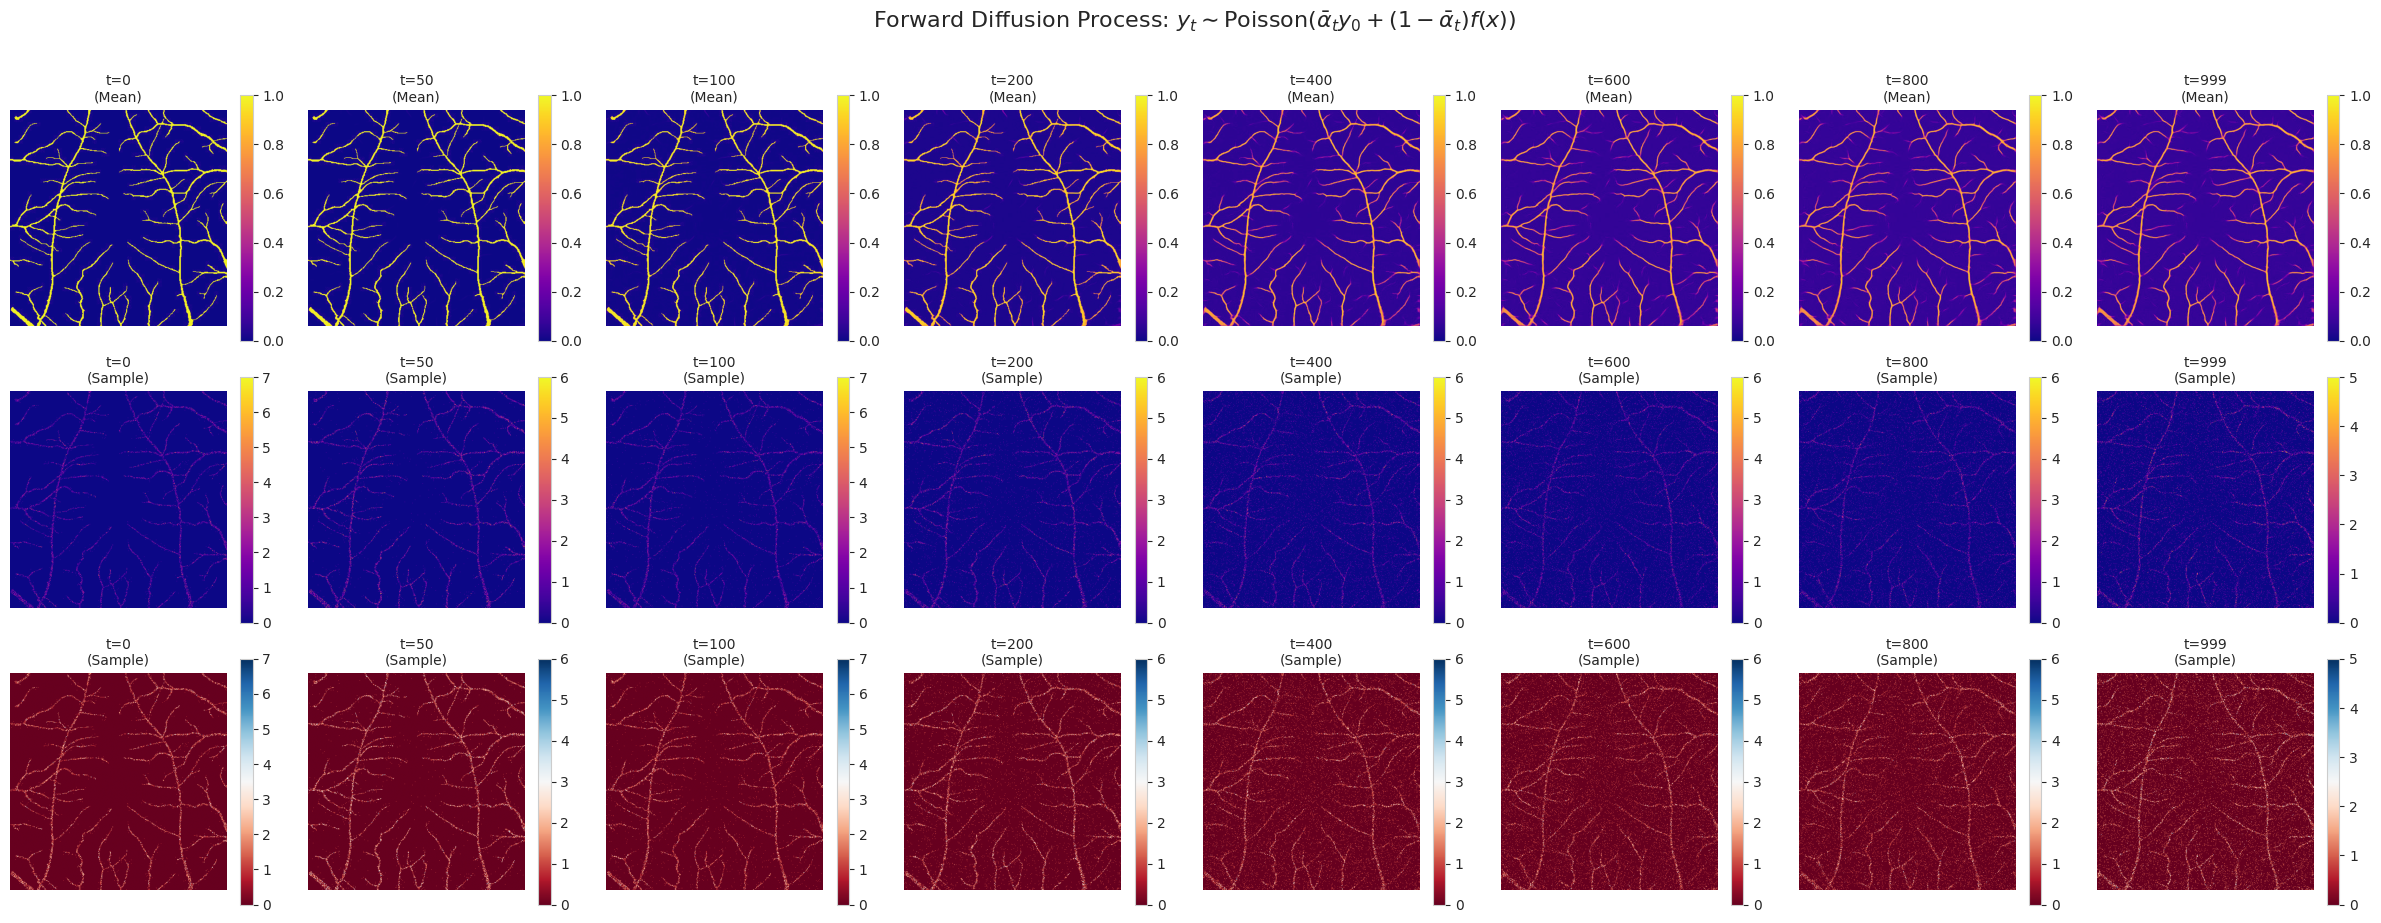

In [7]:
# Visualize forward process for first sample
sample_idx = 0

fig, axes = plt.subplots(3, num_steps, figsize=(num_steps*3, 9))

for i, t_val in enumerate(timesteps_to_visualize):
    # Plot mean
    mean = forward_means[i][sample_idx, 0].cpu().numpy()
    print("mean", "\t", f"{mean.min():.4f}", "\t", f"{mean.mean():.4f}", "\t", f"{mean.max():.4f}")
    axes[0, i].imshow(mean, cmap='plasma', vmin=0, vmax=1)
    axes[0, i].set_title(f't={t_val}\n(Mean)', fontsize=10)
    axes[0, i].axis('off')
    plt.colorbar(axes[0, i].images[0], ax=axes[0, i])

    # Plot sample
    sample = forward_samples[i][sample_idx, 0].cpu().numpy()
    print("sample", "\t", f"{sample.min():.4f}", "\t", f"{sample.mean():.4f}", "\t", f"{sample.max():.4f}")
    axes[1, i].imshow(sample, cmap='plasma', vmin=0)
    axes[1, i].set_title(f't={t_val}\n(Sample)', fontsize=10)
    axes[1, i].axis('off')
    plt.colorbar(axes[1, i].images[0], ax=axes[1, i])

    axes[2, i].imshow(sample, cmap='RdBu', vmin=0)
    axes[2, i].set_title(f't={t_val}\n(Sample)', fontsize=10)
    axes[2, i].axis('off')
    plt.colorbar(axes[2, i].images[0], ax=axes[2, i])

plt.suptitle(r'Forward Diffusion Process: $y_t \sim \mathrm{Poisson}(\bar{\alpha}_t y_0 + (1-\bar{\alpha}_t) f(x))$', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Backward Process (Reverse Diffusion)

역확산 과정을 시뮬레이션합니다.

In [14]:
from src.loss.losses import focal_loss, poisson_kl, poisson_log_likelihood
from src.model.basic_module import mean_flat

model_kwargs = {"prior": prior}
y_t = diffusion.q_sample(y_start, model_kwargs["prior"], t)

terms = {}

true_mean = diffusion.q_posterior_mean(y_start=y_start, y_t=y_t, p=model_kwargs["prior"], t=t)
out = diffusion.p_mean(model, y_t, t, model_kwargs=model_kwargs)
kl = poisson_kl(true_mean, out["mean"])

kl = mean_flat(kl) / np.log(2.0)

decoder_nll = -poisson_log_likelihood(y_start, lambdas=out["mean"])
assert decoder_nll.shape == y_start.shape
decoder_nll = mean_flat(decoder_nll) / np.log(2.0)

output = torch.where((t == 0), decoder_nll, kl)

terms["loss"] = output

target = {
    ModelMeanType.PREVIOUS_Y: diffusion.q_posterior_mean(
        y_start=y_start, y_t=y_t, p=model_kwargs["prior"], t=t
    ),
    ModelMeanType.START_Y: y_start,
    ModelMeanType.EPSILON: diffusion._predict_ystart_from_eps(y_t=y_t, t=t, eps=y_start),
}[diffusion.model_mean_type]
model_output = model(y_t, diffusion._scale_timesteps(t), **model_kwargs)
terms["focal"] = focal_loss(model_output, target) / np.log(2.0)
terms["vb"] = terms["loss"]
terms["loss"] = terms["vb"] + terms["focal"]

## 7. Visualize true_mean, out, and target

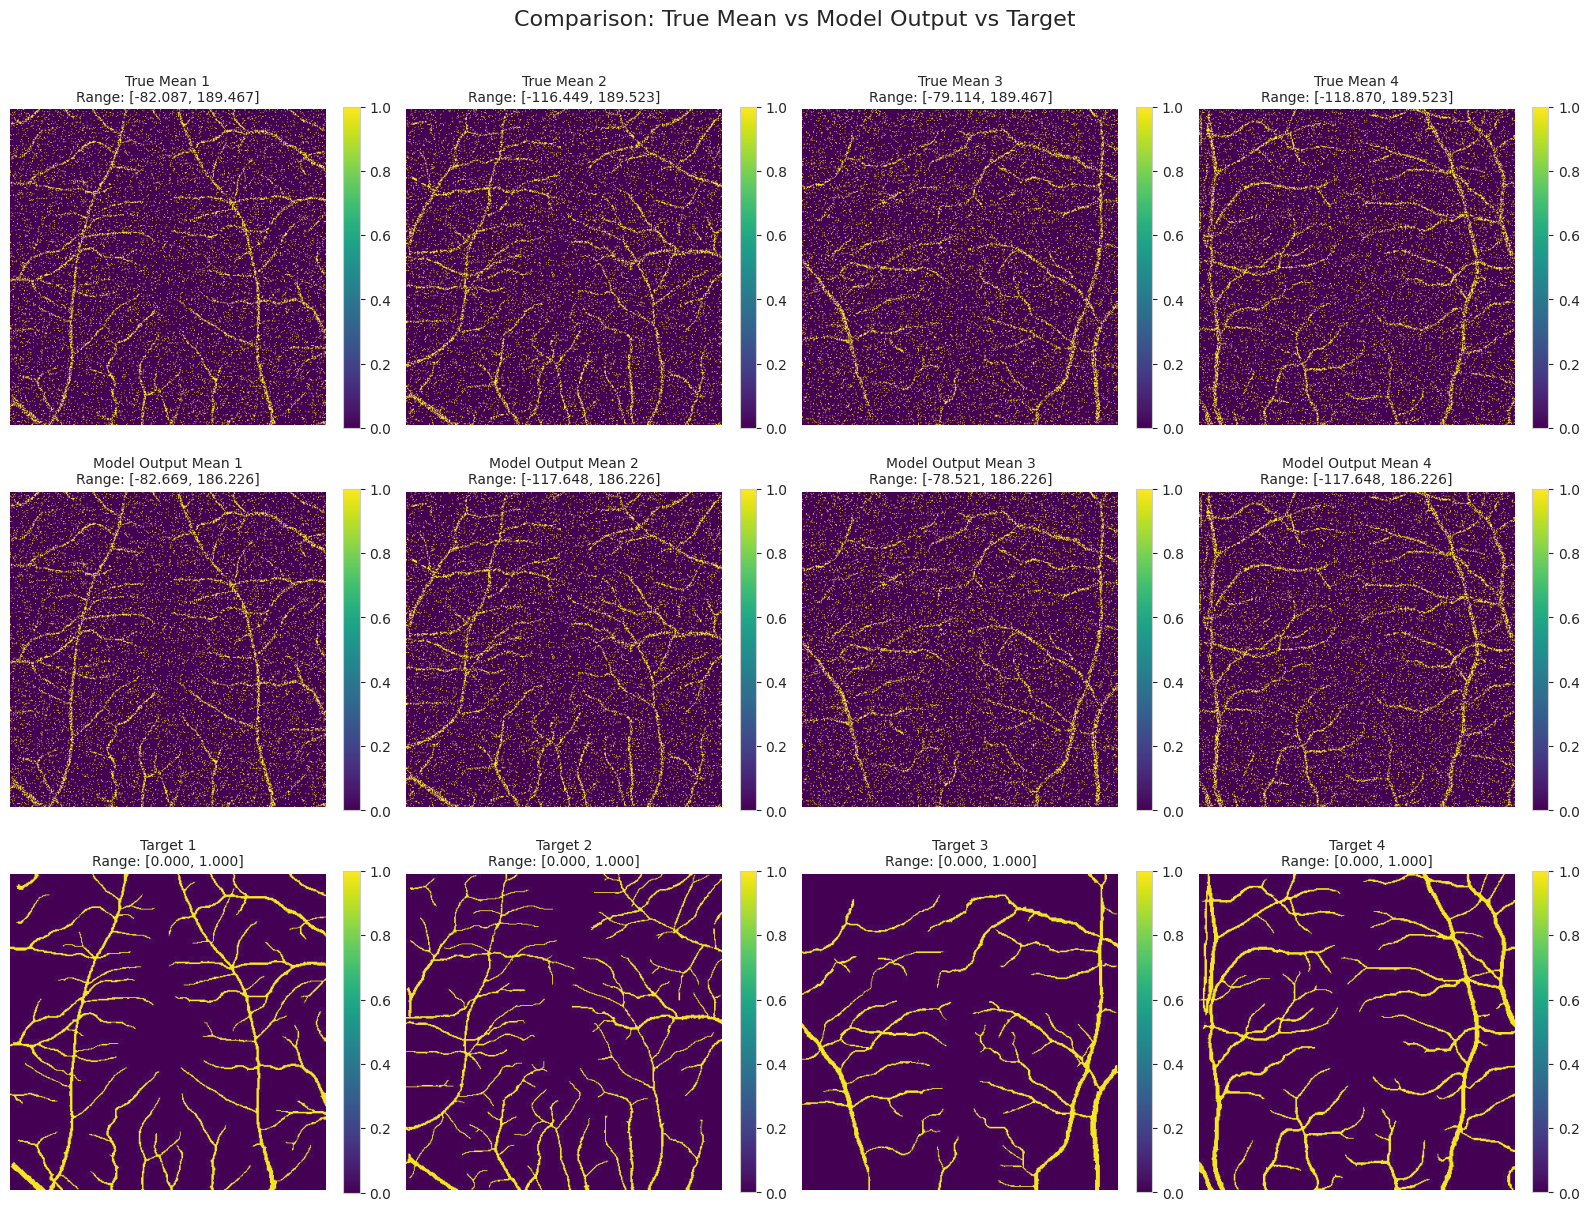

In [15]:
# Visualize true_mean, out['mean'], and target for all samples
fig, axes = plt.subplots(3, batch_size, figsize=(batch_size*4, 12))

for i in range(batch_size):
    # True mean (posterior mean from forward process)
    tm = true_mean[i, 0].cpu().numpy()
    axes[0, i].imshow(tm, cmap='viridis', vmin=0, vmax=1)
    axes[0, i].set_title(f'True Mean {i+1}\nRange: [{tm.min():.3f}, {tm.max():.3f}]', fontsize=10)
    axes[0, i].axis('off')
    plt.colorbar(axes[0, i].images[0], ax=axes[0, i], fraction=0.046)

    # Model output mean
    out_mean = out['mean'][i, 0].cpu().detach().numpy()
    axes[1, i].imshow(out_mean, cmap='viridis', vmin=0, vmax=1)
    axes[1, i].set_title(f'Model Output Mean {i+1}\nRange: [{out_mean.min():.3f}, {out_mean.max():.3f}]', fontsize=10)
    axes[1, i].axis('off')
    plt.colorbar(axes[1, i].images[0], ax=axes[1, i], fraction=0.046)

    # Target
    tgt = target[i, 0].cpu().numpy()
    axes[2, i].imshow(tgt, cmap='viridis', vmin=0, vmax=1)
    axes[2, i].set_title(f'Target {i+1}\nRange: [{tgt.min():.3f}, {tgt.max():.3f}]', fontsize=10)
    axes[2, i].axis('off')
    plt.colorbar(axes[2, i].images[0], ax=axes[2, i], fraction=0.046)

plt.suptitle('Comparison: True Mean vs Model Output vs Target', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()